In [1]:
# This file is licensed under the MIT License.
# See the LICENSE file in the project root for full license information.
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy.special import rel_entr
from envs.forked_riverswim import ForkedRiverSwim
from envs.riverswim import RiverSwim
from typing import Dict, Tuple
from itertools import product
import lzma
from utils.utils import  policy_iteration
from scipy.stats import t
from make_agent import AgentType
from simulation_parameters import EnvType
from run import SequencedResults
import seaborn as sns
import pandas as pd

def TV(p,q):
    return np.sum(np.abs(p-q), -1) * 0.5

def CE(x, c=0.95):
    N = x.shape[0]
    alpha = c + (1-c)/2
    c = t.ppf(alpha, N)
    s = np.std(x, axis=0, ddof=1)
    return x.mean(0), c * s/ np.sqrt(N)

    
compute_dist_omega = lambda x,y: TV(x,y)
compute_dist_value = lambda V, mdp: np.linalg.norm(V -mdp.V_greedy[np.newaxis, np.newaxis], axis=-1)

In [2]:
import shutil
import subprocess

TITLE_SIZE = 22
LEGEND_SIZE = 15
TICK_SIZE = 14
AXIS_TITLE = 22
XAXIS_LABEL = 22
AXIS_LABEL = 22
FONT_SIZE = 14


def _latex_has_package(pkg: str) -> bool:
    kpse = shutil.which("kpsewhich")
    if not kpse:
        return False
    try:
        result = subprocess.run([kpse, pkg], check=False, capture_output=True, text=True)
        return result.stdout.strip() != ""
    except Exception:
        return False


use_tex = (
    shutil.which("latex") is not None
    and _latex_has_package("newtxtext.sty")
    and _latex_has_package("newtxmath.sty")
)

rc_parameters = {
    "font.size": FONT_SIZE,
    "axes.titlesize": AXIS_TITLE,
    "axes.labelsize": AXIS_LABEL,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "figure.titlesize": TITLE_SIZE,
    "font.family": "serif",  # use serif/main font for text elements
    "text.usetex": use_tex,  # render via LaTeX when available
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}
if use_tex:
    rc_parameters["text.latex.preamble"] = r"""
        \usepackage{newtxtext}
        \usepackage{newtxmath}
    """

plt.rcParams.update(rc_parameters)


In [3]:
lengths = [
    (5, EnvType.RIVERSWIM),
    (3, EnvType.FORKED_RIVERSWIM),
    (10, EnvType.RIVERSWIM),
    (5, EnvType.FORKED_RIVERSWIM),
    (20, EnvType.RIVERSWIM),
    (10, EnvType.FORKED_RIVERSWIM),
    (30, EnvType.RIVERSWIM),
    (15, EnvType.FORKED_RIVERSWIM),
    (50, EnvType.RIVERSWIM),
    (25, EnvType.FORKED_RIVERSWIM)
]
agents = [
    AgentType.MDP_NAS, AgentType.PS_MDP_NAS, AgentType.O_BPI,
    AgentType.Q_UCB, AgentType.PSRL, AgentType.BAYES_MFBPI,
    AgentType.Q_LEARNING, AgentType.VarDE_Q_LEARNING,
]

data: Dict[Tuple[int, EnvType, AgentType],  SequencedResults] = {}
for env_type, agent in product(lengths, agents):
    length, env = env_type
    data[(length, env, agent)] = None
    
    print(f"> Opening {env.value}/{agent.value}/{length}")
    with lzma.open(f'data/{env.value}/{agent.value}_{length}.pkl.lzma', 'rb') as f:
        res  = pickle.load(f)
        data[(length, env, agent)] = res

> Opening Riverswim/MDP-NaS/5
> Opening Riverswim/PS-MDP-NaS/5
> Opening Riverswim/O-BPI/5
> Opening Riverswim/Q-UCB/5
> Opening Riverswim/PSRL/5
> Opening Riverswim/Bayes-MFBPI/5
> Opening Riverswim/Q-Learning/5
> Opening Riverswim/VarDE-Q-Learning/5
> Opening ForkedRiverswim/MDP-NaS/3
> Opening ForkedRiverswim/PS-MDP-NaS/3
> Opening ForkedRiverswim/O-BPI/3
> Opening ForkedRiverswim/Q-UCB/3
> Opening ForkedRiverswim/PSRL/3
> Opening ForkedRiverswim/Bayes-MFBPI/3
> Opening ForkedRiverswim/Q-Learning/3
> Opening ForkedRiverswim/VarDE-Q-Learning/3
> Opening Riverswim/MDP-NaS/10
> Opening Riverswim/PS-MDP-NaS/10
> Opening Riverswim/O-BPI/10
> Opening Riverswim/Q-UCB/10
> Opening Riverswim/PSRL/10
> Opening Riverswim/Bayes-MFBPI/10
> Opening Riverswim/Q-Learning/10
> Opening Riverswim/VarDE-Q-Learning/10
> Opening ForkedRiverswim/MDP-NaS/5
> Opening ForkedRiverswim/PS-MDP-NaS/5
> Opening ForkedRiverswim/O-BPI/5
> Opening ForkedRiverswim/Q-UCB/5
> Opening ForkedRiverswim/PSRL/5
> Opening Fo

In [8]:
labels_agents = {
    AgentType.PSRL: 'PSRL',
    AgentType.Q_UCB: 'Q-UCB',
    AgentType.MDP_NAS: 'MDP-NaS',
    AgentType.BAYES_MFBPI: 'MF-BPI',
    AgentType.O_BPI: 'O-BPI',
    AgentType.PS_MDP_NAS: 'PS-MDP-NaS',
    AgentType.Q_LEARNING: 'Q-Learning',
    AgentType.VarDE_Q_LEARNING: 'VarDE Q-Learning',
}

def find_first_below_threshold(matrix, threshold=0.05):
    # Create a boolean mask of elements less than the threshold
    mask = matrix < threshold
    
    # For each row, find the first occurrence of a value below the threshold and return the index
    indices = np.array([np.argmax(row) if np.any(row) else len(row) for row in mask])
    
    return indices

df = pd.DataFrame({
    'N': [],
    'Environment': [],
    'Agent': [],
    't_hit': []
})
for length, env_type in lengths:
    if env_type == EnvType.RIVERSWIM:
        env = RiverSwim(length)
    else:
        env = ForkedRiverSwim(length)
    Vgreedy, _, _ =policy_iteration(0.99, env.transitions, env.rewards)
    for agent in agents:
        x = data[(length, env_type, agent)].dist_value_infinity / np.max(Vgreedy)
        idxs =  1 - x[:,-1] #find_first_below_threshold(x)* data[(length, env_type, agent)].simulation_parameters.frequency_evaluation
        for i in idxs:
            _length = length * 2 -1 if env_type == EnvType.FORKED_RIVERSWIM else length
            df.loc[len(df)] = [_length, env_type.value, labels_agents[agent], i]

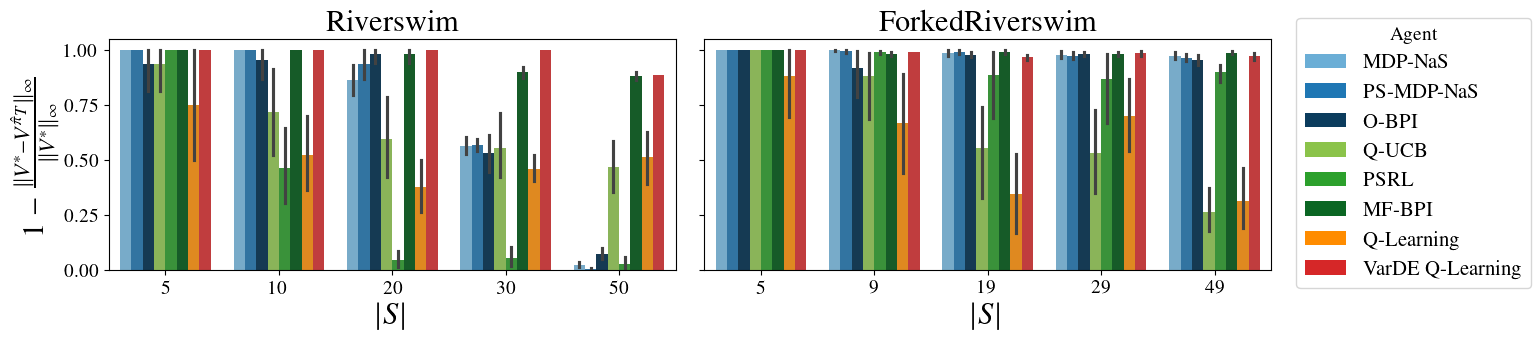

In [10]:
from matplotlib.patches import Patch
colors = ["#6BAED6","#1F77B4","#0B3C5D","#8BC34A","#2CA02C","#0B6623","#FF8C00","#D62728"]
filtered_df = df
unique_agents = filtered_df['Agent'].unique()
agents_colors = ['MDP-NaS', 'PS-MDP-NaS', 'O-BPI', 'Q-UCB', 'PSRL', 'MF-BPI', 'Q-Learning', 'VarDE Q-Learning']

color_dict = {agent: color for agent, color in zip(agents_colors, colors)}

fig, axes = plt.subplots(1,2, sharey=True, figsize=(15, 3),)
for ax_id, environment in enumerate([EnvType.RIVERSWIM.value, EnvType.FORKED_RIVERSWIM.value]):
    env_data = filtered_df[filtered_df['Environment'] == environment]
    sns.barplot(x="N", y="t_hit", hue="Agent", data=env_data, palette=color_dict, ax=axes[ax_id], hue_order=[labels_agents[x]for x in agents], legend=False)
    axes[ax_id].set_xlabel('$|S|$')#if environment == EnvType.RIVERSWIM.value else '$N$')
    axes[ax_id].set_title(r'\rm{' + environment + '}')

axes[1].set_ylabel('')
axes[0].set_ylabel(r"$1-\frac{\|V^* - V^{\hat\pi_T}\|_\infty}{\|V^*\|_\infty}$")
plt.subplots_adjust(wspace=0.05)
legend_labels = [labels_agents[x] for x in agents]
handles = [Patch(facecolor=color_dict[label], label=label) for label in legend_labels]
labels = legend_labels

# Manually reorder the handles and labels
# ordered_handles = [handles[1], handles[2], handles[5],handles[0], handles[3], handles[4], handles[6]]  # Change the order as desired
# ordered_labels = [labels[1], labels[2], labels[5], labels[0], labels[3], labels[4], labels[6]]  # Change the order as desired

fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.08, 0.5), title='Agent')

plt.savefig('figures/bpi.pdf', bbox_inches='tight')

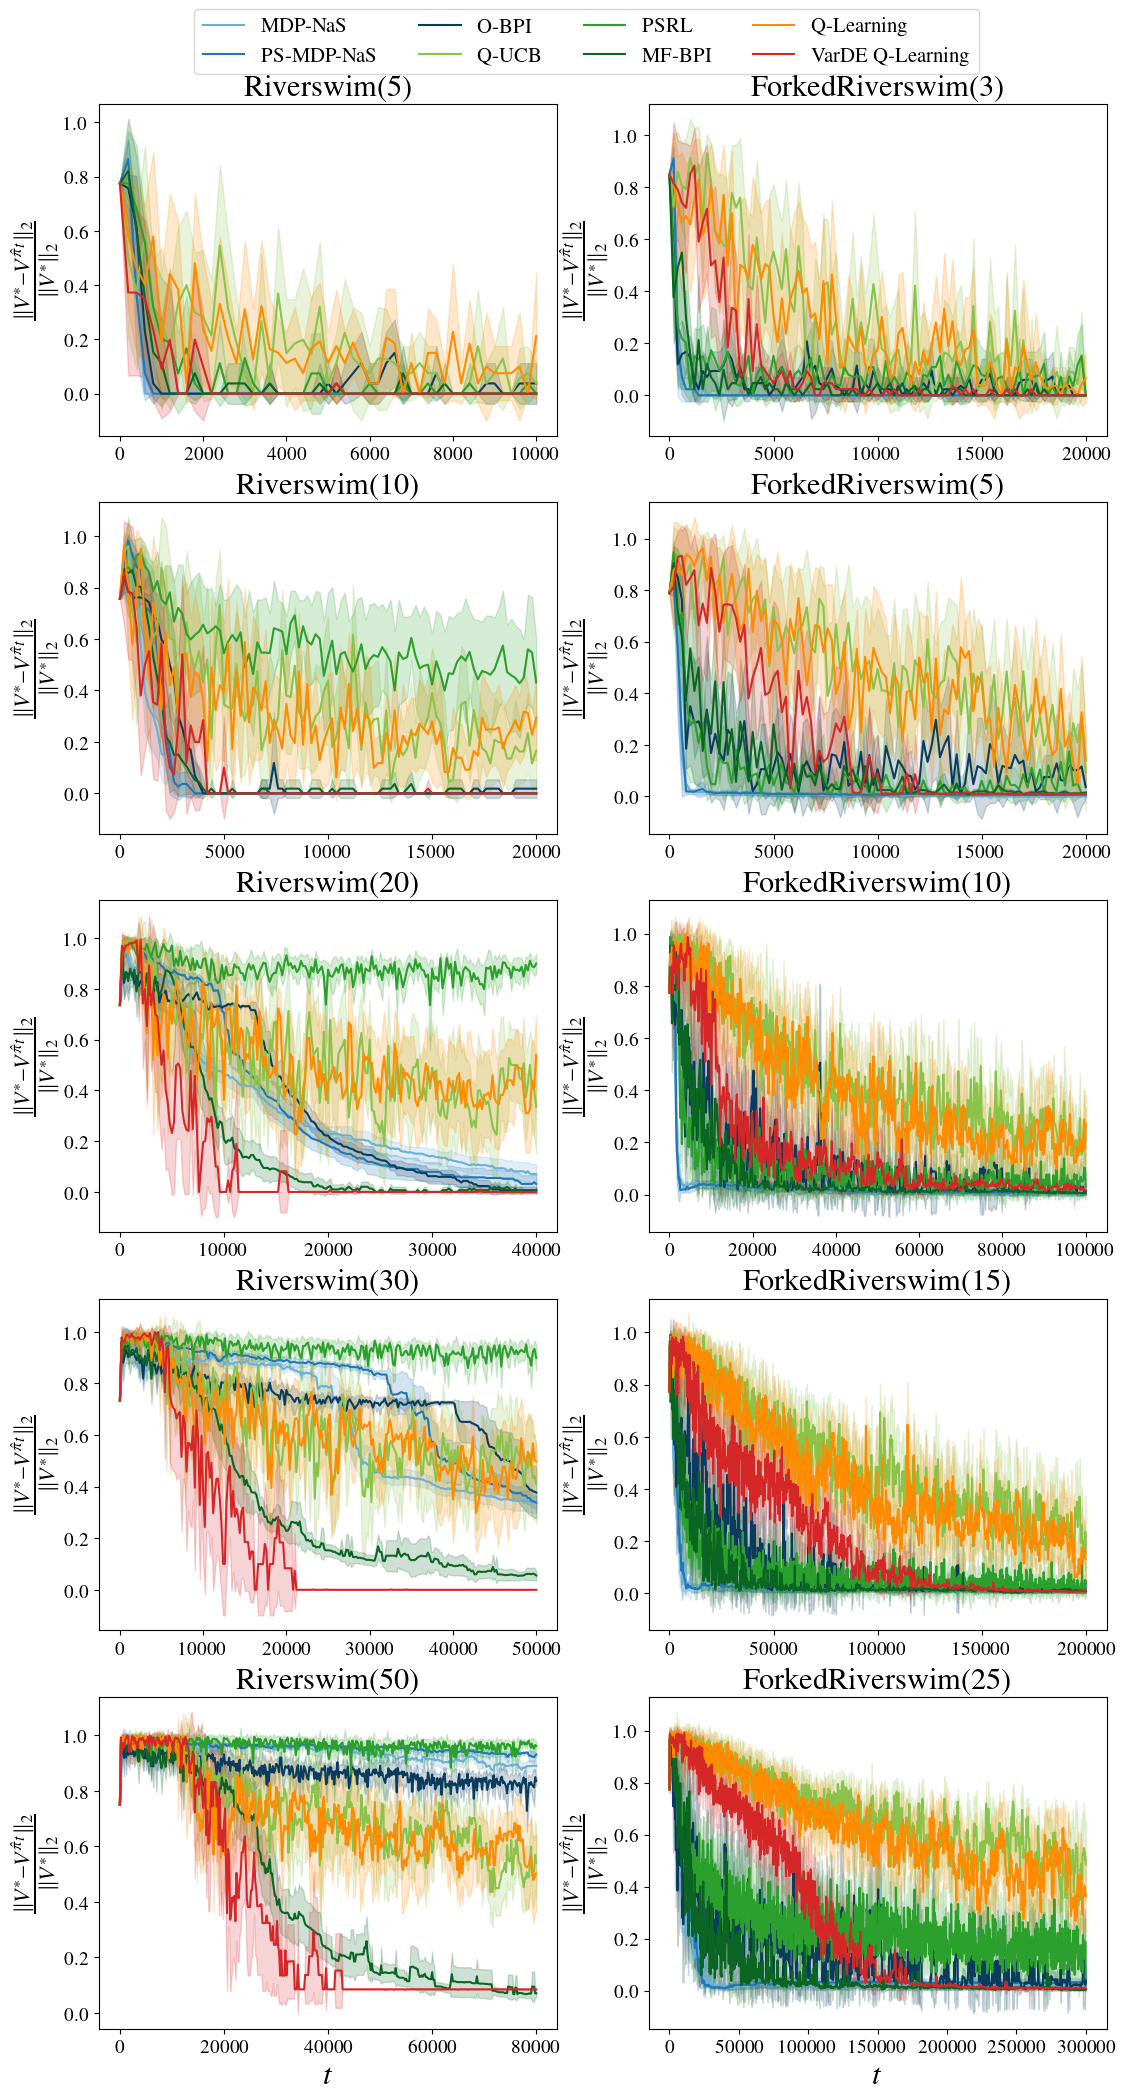

In [11]:
fig, ax = plt.subplots(5, 2 ,figsize=(13,25))

linestyle = {
    AgentType.Q_UCB: "solid", 
    AgentType.Q_LEARNING: "solid", 
    AgentType.BAYES_MFBPI: "solid",
    AgentType.FORCED_MFBPI: "solid",
    AgentType.PSRL: "solid",
    AgentType.MDP_NAS: "solid",
    AgentType.O_BPI: 'solid',
    AgentType.PS_MDP_NAS: 'solid',
    AgentType.VarDE_Q_LEARNING: 'solid',
    AgentType.VarDEMFBPI: 'solid',
}

id_l = 0
for length, env_type in lengths:
    if env_type == EnvType.RIVERSWIM:
        env = RiverSwim(length)
    else:
        env = ForkedRiverSwim(length)
    Vgreedy, _, _ =policy_iteration(0.99, env.transitions, env.rewards)
    
    id_e = 0 if env_type == EnvType.RIVERSWIM else 1

    if env_type == EnvType.RIVERSWIM:
        id_l = 0 if length == 5 else 1 if length == 10 else 2 if length == 20 else 3 if length == 30 else 4
    else:
        id_l = 0  if length == 3 else 1 if length == 5 else 2 if length == 10 else 3 if length == 15 else 4
    for agent_id,  agent in enumerate(agents):
        parameters=  data[(length, env_type, agent)].simulation_parameters
        x = range(0, parameters.horizon + 1, parameters.frequency_evaluation)

        df = pd.DataFrame(data[(length, env_type, agent)].dist_value / np.linalg.norm(Vgreedy))
        df = df.stack().reset_index()
        df.columns = ['Run', 't', 'Value']
        alpha = 0.05  # Adjust this for the desired confidence level (e.g., 0.05 for 95% confidence intervals)
        grouped_data = df.groupby('t')['Value'].agg(['mean', 'sem'])
        grouped_data['lower'] = grouped_data['mean'] - t.ppf(1 - alpha/2, len(data)-1) * grouped_data['sem']
        grouped_data['upper'] = grouped_data['mean'] + t.ppf(1 - alpha/2, len(data)-1) * grouped_data['sem']
        grouped_data.reset_index(inplace=True)
        ax[id_l, id_e].plot(grouped_data['t'] * parameters.frequency_evaluation, grouped_data['mean'],label=labels_agents[agent], linestyle=linestyle[agent], color=colors[agent_id])
        ax[id_l, id_e].fill_between(grouped_data['t'] * parameters.frequency_evaluation, grouped_data['lower'], grouped_data['upper'], alpha=0.2,  color=colors[agent_id])

        #mu, ce = CE(data[(length, env_type, agent)].dist_value / np.linalg.norm(Vgreedy))
        #ax[id_l, id_e].plot(x, mu, label=labels[agent], linestyle=linestyle[agent], color=colors[agent_id])
        #ax[id_l, id_e].fill_between(x, mu-ce, mu+ce, alpha=0.2)
        #sns.lineplot(x='t', y='Value', data=df, errorbar=('ci', 95))
    #ax[id_l, id_e].grid()
    #if id_l == 0:
    ax[id_l, id_e].set_title(r'\textrm{' + f'{env_type.value}({length})' + '}')

    ax[id_l, id_e].set_ylabel(r'$\frac{\|V^* - V^{\hat\pi_t}\|_2}{\|V^*\|_2}$')

    if id_l == 4:
        ax[id_l, id_e].set_xlabel('$t$')

# plt.subplots_adjust(wspace=0.05)
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, .922), frameon=True, ncols = 4)

plt.savefig('figures/full.pdf', bbox_inches='tight')